# 1. Imports

In [479]:
import numpy as np 
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

!pip install missingno
import missingno as msno

from sklearn.impute import SimpleImputer

# 2. Load data

In [480]:
!cd "/Users/grace/Documents/GitHubRepos/capstone2_immunization/"
data = pd.read_csv("/Users/grace/Documents/GitHubRepos/capstone2_immunization/imm_df_cleaned.csv")

In [481]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 41 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   county_name                                    1016 non-null   object 
 1   % Low Birthweight                              470 non-null    float64
 2   # Primary Care Physicians                      934 non-null    float64
 3   Primary Care Physicians Rate                   934 non-null    float64
 4   % Vaccinated Flu                               1008 non-null   float64
 5   % Children in Poverty                          1016 non-null   float64
 6   Infant Mortality Rate                          304 non-null    float64
 7   # Uninsured Children                           1016 non-null   int64  
 8   % Uninsured Children                           1016 non-null   float64
 9   # Food Insecure                                1016 

In [482]:
# examine missing data per variable
missing_df = pd.DataFrame({'# Missing':data.isnull().sum(),'% Missing': round(data.isnull().sum()/len(data),2)})
missing_df.sort_values(by = '% Missing', ascending = False)

,# Missing,% Missing
Infant Mortality Rate,712,0.70
% Low Birthweight,546,0.54
% Broadband Access,508,0.50
% Less Than 18 Years of Age,508,0.50
Segregation index_b,345,0.34
live_births,278,0.27
% Female,254,0.25
% Rural,254,0.25
Primary Care Physicians Rate,82,0.08
# Primary Care Physicians,82,0.08


In [483]:
data['year'].unique()

array([2020, 2021, 2022, 2023])

# 3.  Exploratory Data Analysis

## Clean and examine numerical variables

In [484]:
numerical_cols = data.select_dtypes(['int','float']).columns
print(len(numerical_cols))
numerical_cols

37


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator'

In [485]:
numerical_cols_subset1 = ['% Low Birthweight',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '% Uninsured Children',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population',  'year', '% Broadband Access', '% Less Than 18 Years of Age', 'mmr_doses_0_24_months']
print(len(numerical_cols_subset1)) 

16


In [486]:
numerical_cols_subset2 = ['% Female', '% Rural','Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout', 'live_births',
       'other_pc_provider_ratio_numerator', 'mmr_doses_2_8_years',
       'mmr_doses_9_17_years','kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov']
print(len(numerical_cols_subset2))

17


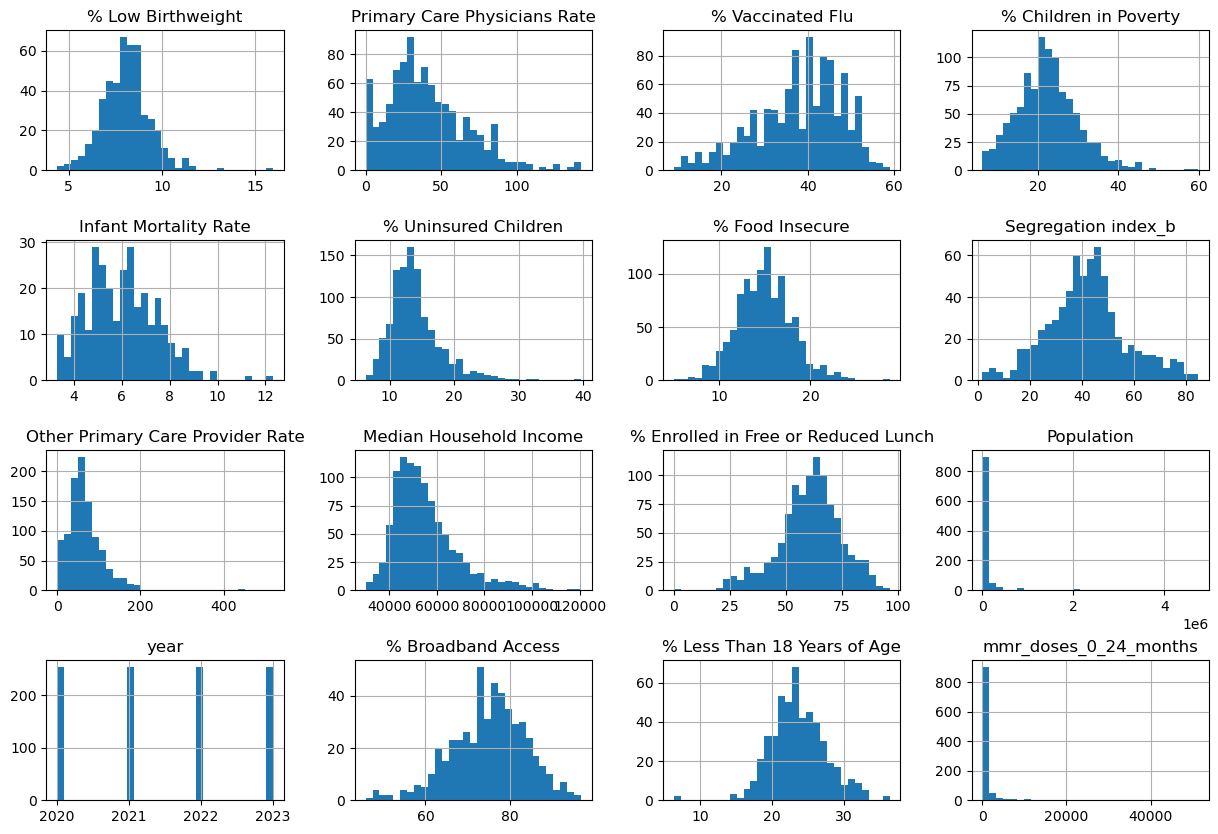

In [487]:
data[numerical_cols_subset1].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

There is a small minority of counties with huge populations. Make sure all the numeric variables are rates or per capita measures so that we don't see trends based on the unevent population county sizes. The main variable to be adjusted is the # of pediatric mmr dose varibles. 
Estimate MMR coverage based on the # of doses and the population of each county.

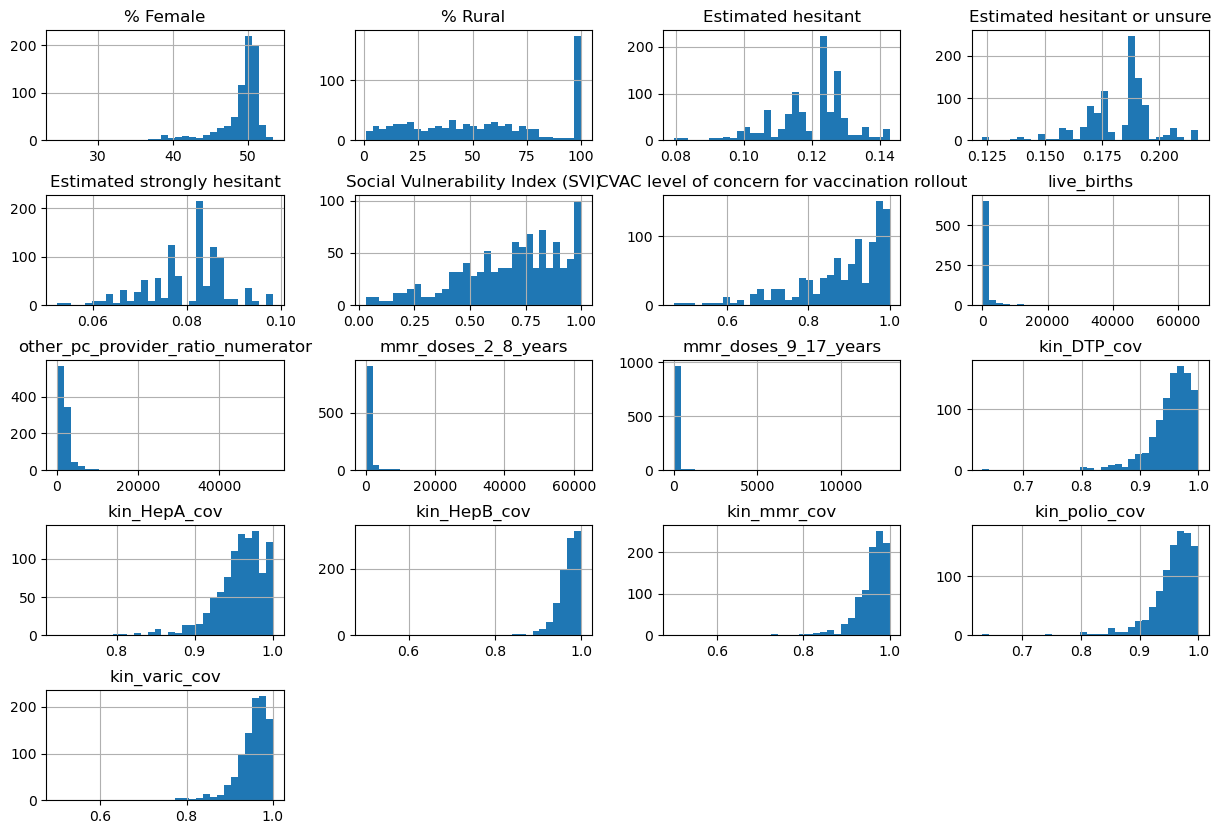

In [488]:
data[numerical_cols_subset2].hist(figsize=(15,10), bins = 31 )
plt.subplots_adjust(hspace=0.5)

Most variables are skewed left (SVI, CVAC levels) or right (immunization coverage levels among kindergarteners).

### County Population Size

In [489]:
# create a categorical variable for county population
p33 = np.percentile(data['Population'], 33.33)
p67 = np.percentile(data['Population'], 66.67)
print(f"33rd percentile: {p33:.0f} \n67th percentile: {p67:.0f}")
data['pop_tertiles'] = data['Population'].apply(lambda x: 'small' if x <p33 else ('medium' if p33<= x <p67 else 'large'))
data['pop_tertiles'].value_counts(dropna = False)

33rd percentile: 9438 
67th percentile: 36548


pop_tertiles
large     339
small     339
medium    338
Name: count, dtype: int64

In [490]:
# check to make sure categories were coded correctly
data['Population'].groupby(by = data['pop_tertiles']).agg('mean')

pop_tertiles
large     320180.823009
medium     19449.360947
small       4339.949853
Name: Population, dtype: float64

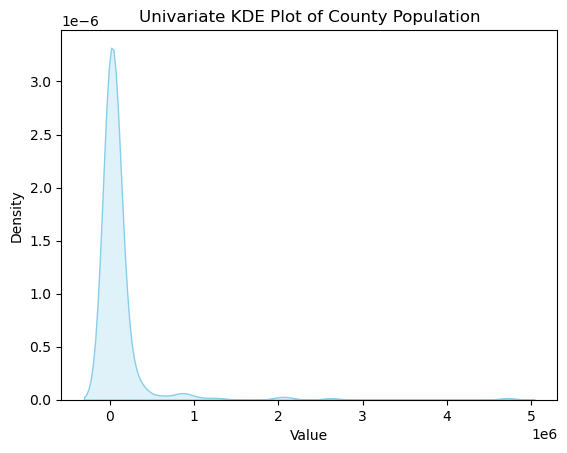

In [491]:
# Examine distribution of Population with kdensity plot
sns.kdeplot(x=data['Population'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [492]:
data['Population'].describe()

count    1.016000e+03
mean     1.147504e+05
std      4.093774e+05
min      5.700000e+01
25%      6.647000e+03
50%      1.864400e+04
75%      5.261150e+04
max      4.738253e+06
Name: Population, dtype: float64

### % Rural

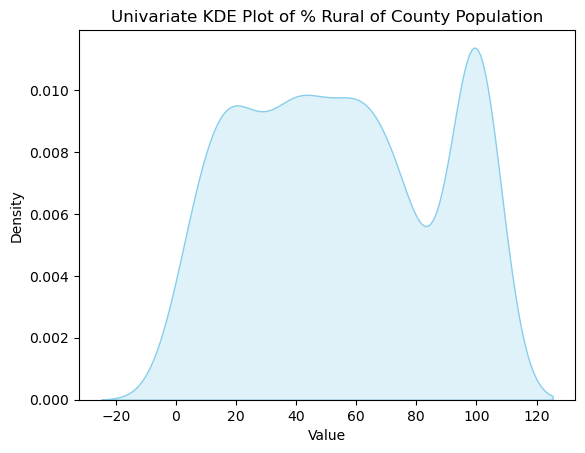

In [493]:
# Examine distribution of % Rural with kdensity plot
sns.kdeplot(x=data['% Rural'], fill=True, color='skyblue')
plt.title('Univariate KDE Plot of % Rural of County Population')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

In [494]:
# ensure there are no negative values
data['% Rural'].describe()

count    762.000000
mean      55.520241
std       31.861401
min        0.688304
25%       27.260558
50%       53.635841
75%       81.316514
max      100.000000
Name: % Rural, dtype: float64

In [495]:
# check to see how county % Rural values varied by year
data['% Rural'].groupby(by = data['year']).agg('mean')

year
2020    55.520241
2021    55.520241
2022          NaN
2023    55.520241
Name: % Rural, dtype: float64

In [496]:
# Looks like the % Rural variable doesn't change at all year to year, but is missing for the 2022 counties
# impute the 2022 values based on other years
year2022mask = data['year'] == 2022
year2023mask = data['year'] == 2023
print(type(year2022mask))
# data.loc[year2022mask, '% Rural'] = data.loc[year2023mask, '% Rural'] didn't work
data['% Rural'].groupby(by = data['year']).agg('mean')

<class 'pandas.core.series.Series'>


year
2020    55.520241
2021    55.520241
2022          NaN
2023    55.520241
Name: % Rural, dtype: float64

In [497]:
# create an index to copy 2023 '% Rural' values to 2022 '% Rural' values
# create dictionary that maps 2023 to 2022 indices
indx_mapping = dict(zip(data[year2023mask].index, data[year2022mask].index))
# Use the mapping to copy values
for idx_2023, idx_2022 in indx_mapping.items():
    data.loc[idx_2022, '% Rural'] = data.loc[idx_2023, '% Rural']

In [498]:
print(data['% Rural'].groupby(by = data['year']).agg('mean'))
pd.crosstab(data['% Rural'].isna().sum(), data['year'], dropna = False)

year
2020    55.520241
2021    55.520241
2022    55.520241
2023    55.520241
Name: % Rural, dtype: float64


year,2020,2021,2022,2023
row_0,,,,
0,254,254,254,254


In [499]:
# create a categorical variable for % rural county population
p25, p50, p75 = np.percentile(data['% Rural'], [25, 50, 75])
print(f"25th percentile: {p25:.0f} \n50th percentile: {p50:.0f}\n75th percentile: {p75:.0f}")

25th percentile: 27 
50th percentile: 54
75th percentile: 81


In [500]:
data['rural_pop_quartiles'] = data['% Rural'].apply(lambda x: 'very urban' if x <p25 else
                                                    ('urban' if p25<= x <p50 else
                                                    ('rural' if p50 <= x <p75 else
                                                    'very rural' )))
print(data['rural_pop_quartiles'].value_counts(dropna = False))

rural_pop_quartiles
urban         256
very rural    256
rural         252
very urban    252
Name: count, dtype: int64


In [501]:
# check categorical variable for % rural population
print(data['% Rural'].groupby(by = data['rural_pop_quartiles']).agg('mean'))

rural_pop_quartiles
rural         66.803258
urban         41.190879
very rural    98.902200
very urban    14.723476
Name: % Rural, dtype: float64


Note that there is a large variation in the % of a county population that is rural. Looks a bit bimodal and a bit uniform from the kdensity plot above.
The quartiles for % Rural can be categorized as very urban (15% rural) all the way to very rural (98% rural).

### % Less Than 18 Years of Age

In [502]:
# examine how th missing data for this variable varies by year & categorical rural pop variable 
print(data['% Less Than 18 Years of Age'].groupby(by = data['rural_pop_quartiles']).agg('mean'))
print(data['% Less Than 18 Years of Age'].groupby(by = data['year']).agg('mean'))


rural_pop_quartiles
rural         23.056409
urban         23.697207
very rural    21.768779
very urban    26.270038
Name: % Less Than 18 Years of Age, dtype: float64
year
2020          NaN
2021    23.746129
2022    23.634888
2023          NaN
Name: % Less Than 18 Years of Age, dtype: float64


Half of the values for this variable appear to be missing for 2020 and 2023. There seem to be a slightly greater % of youth living in very urban counties relative to very rural counties. But there isn't much difference in the % of youth in rural vs. urban counties. The percentages in 2021 and 2022 aren't very different.

In [503]:
youth_vs_year = data[['% Less Than 18 Years of Age','year']]
(youth_vs_year
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)
# the weak correlation between the two columns suggests that we can use the existing % <18 yrs column to extrapolate for other years

,% Less Than 18 Years of Age,year
% Less Than 18 Years of Age,1.000000,-0.014514
year,-0.014514,1.000000


Impute the missing % Less than 18 years of Age values by taking the average of 2021 and 2022 values, and using those for the 2020 and 2023 values. Use the missing indicator method (MIM) to also create a dummary variable indicating which % Youth population values were originally missing with the (SimpleImputer)[https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html].

In [504]:
# create masks for remaining years
year2020mask = data['year'] == 2020
year2021mask = data['year'] == 2021

In [505]:
# impute values for the missing '% Less than 18 Years of Age' column
imputer = SimpleImputer(strategy = 'median', add_indicator = True)
x = imputer.fit_transform(data[['% Less Than 18 Years of Age']])
print(type(x))
imputed_youth_df = pd.DataFrame(x, columns = ['%_pop_youth_imputed', '%_pop_youth_imputed_yes_no'])

<class 'numpy.ndarray'>


In [506]:
# add imputed youth variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %youth data frame shape: {imputed_youth_df.shape}")
data_test = pd.concat([data,imputed_youth_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 43)
Imputed %youth data frame shape: (1016, 2)
Combined data frame shape: (1016, 45)


In [507]:
age_cols = ['% Less Than 18 Years of Age', '%_pop_youth_imputed', '%_pop_youth_imputed_yes_no']

In [508]:
print(data_test[age_cols].groupby(by = data_test['year']).agg('mean'))

      % Less Than 18 Years of Age  %_pop_youth_imputed  \
year                                                     
2020                          NaN            23.469542   
2021                    23.746129            23.746129   
2022                    23.634888            23.634888   
2023                          NaN            23.469542   

      %_pop_youth_imputed_yes_no  
year                              
2020                         1.0  
2021                         0.0  
2022                         0.0  
2023                         1.0  


In [509]:
# check
print(pd.crosstab(data_test['% Less Than 18 Years of Age'].isna().sum(), data_test['year'], margins = True, dropna = False))
pd.crosstab(data_test['%_pop_youth_imputed'].isna().sum(), data_test['year'], margins = True, dropna = False)

year   2020  2021  2022  2023   All
row_0                              
508     254   254   254   254  1016
All     254   254   254   254  1016


year,2020,2021,2022,2023,All
row_0,,,,,
0,254,254,254,254,1016
All,254,254,254,254,1016


In [510]:
# save changes with imputed data back to the original data frame
data = data_test

Confirmed that data for the % pop <18 years old was imputed for 2020 and 2023. We have now two new columns for each county.
There is no missing data for the %_pop_youth_imputed'

### Infant mortality rate


In [511]:
pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['year'], margins = True, dropna = False)

year,2020,2021,2022,2023,All
row_0,,,,,
712,254,254,254,254,1016
All,254,254,254,254,1016


There are 712 values missing for each year? 

In [512]:
pd.crosstab(data['Infant Mortality Rate'].isna().sum(), data['rural_pop_quartiles'], margins = True, dropna = False)

rural_pop_quartiles,rural,urban,very rural,very urban,All
row_0,,,,,
712,252,256,256,252,1016
All,252,256,256,252,1016


In [513]:
# examine the patterns of missing data for 'Infant Mortality Rate' before imputation
imr_missing_correlations = data[['Infant Mortality Rate','year','% Rural','Population']]
(imr_missing_correlations
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,Infant Mortality Rate,year,% Rural,Population
Infant Mortality Rate,1.000000,-0.076496,0.364619,-0.140222
year,-0.076496,1.000000,-0.000000,0.003059
% Rural,0.364619,-0.000000,1.000000,-0.358607
Population,-0.140222,0.003059,-0.358607,1.000000


In [514]:
# impute values for the missing column
x = imputer.fit_transform(data[['Infant Mortality Rate']])
print(type(x))
imputed_imr_df = pd.DataFrame(x, columns = ['imr_imputed', 'imr_imputed_yes_no'])

<class 'numpy.ndarray'>


In [515]:
# add imputed variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %imputed_imr_df data frame shape: {imputed_imr_df.shape}")
data_test = pd.concat([data,imputed_imr_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 45)
Imputed %imputed_imr_df data frame shape: (1016, 2)
Combined data frame shape: (1016, 47)


In [516]:
imr_cols = ['Infant Mortality Rate', 'imr_imputed', 'imr_imputed_yes_no']

In [517]:
print(data_test[imr_cols].groupby(by = data_test['year']).agg('mean'))

      Infant Mortality Rate  imr_imputed  imr_imputed_yes_no
year                                                        
2020               6.166375     6.028579            0.688976
2021               6.100723     6.006044            0.704724
2022               5.901742     5.947290            0.704724
2023               5.901742     5.947290            0.704724


In [518]:
# save changes over original
data = data_test

### Live_births

In [519]:
pd.crosstab(data['live_births'].isna().sum(),data['year'], margins = True, dropna= False)

year,2020,2021,2022,2023,All
row_0,,,,,
278,254,254,254,254,1016
All,254,254,254,254,1016


In [520]:
# impute values for the missing column
x = imputer.fit_transform(data[['live_births']])
imputed_live_births_df = pd.DataFrame(x, columns = ['live_births_imputed', 'live_births_imputed_yes_no'])

In [521]:
imputed_live_births_df.head()

,live_births_imputed,live_births_imputed_yes_no
0,543.0,0.0
1,287.0,0.0
2,1167.0,0.0
3,171.0,0.0
4,69.0,0.0


In [522]:
# add imputed variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %live birth data frame shape: {imputed_live_births_df.shape}")
data_test = pd.concat([data,imputed_live_births_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 47)
Imputed %live birth data frame shape: (1016, 2)
Combined data frame shape: (1016, 49)


In [523]:
lb_cols = ['live_births','live_births_imputed', 'live_births_imputed_yes_no']

In [524]:
print(data_test[lb_cols].groupby(by = data_test['year']).agg('mean'))

      live_births  live_births_imputed  live_births_imputed_yes_no
year                                                              
2020  1497.040650          1456.614173                    0.031496
2021  1512.838057          1477.029528                    0.027559
2022  1590.861224          1542.057087                    0.035433
2023          NaN           213.500000                    1.000000


In [525]:
# save modified over original
data = data_test

Now that I have imputed the # of live births and the infant mortality rate in each county and year, I can use this to estimate the number of children that are 0-24 months old, which I will need to calulate MMR vaccine coverage for that age group. 

Infant mortality rate is the # of infant deaths between 0-12 months per 1000 live births.

In [526]:
# calculate the # of children under 24 months in each county based on the number of live births and the IMR
data['pop_0_24mos'] = data['live_births_imputed']-((data['imr_imputed']/1000)* data['live_births_imputed'])

Technically, pop_0_24mos is the # of infants who survived the first year of life. However, since the IMR during 12-23 months is generally lower than in the first 12 months of old. This is a good approximation. It's also appropriate given the # of doses are for all children 0-24 months of old, and 12 months falls exactly in the middle of that age range.

In [527]:
print(data[['live_births_imputed','pop_0_24mos','imr_imputed']].groupby(by = data['year']).agg('mean'))

      live_births_imputed  pop_0_24mos  imr_imputed
year                                               
2020          1456.614173  1448.240116     6.028579
2021          1477.029528  1468.620604     6.006044
2022          1542.057087  1533.436565     5.947290
2023           213.500000   212.230254     5.947290


### # of MMR Doses per Child

In [528]:
data.filter(like = 'mmr').columns

Index(['mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'kin_mmr_cov'],
      dtype='object')

In [529]:
data.filter(like = '18').columns

Index(['% Less Than 18 Years of Age'], dtype='object')

The general formula for calculating pediatric MMR vaccination coverage is:
- '# of kids that received a certain # of doses in an age group/ # of kids in that age group.' 

I don't have denominators for all of these MMR dose numerators, only for the mmr_doses_0_24_months.
Try creating new var that has total # of mmr_doses from 0-18 yrs. Given I already have the % of the population below 18 years old, this seems like an indicator that's easy to calculate that might come in handy later. 

In [530]:
# calculate dose rate for 0-24 month old kids, scale this to be # of doses per 100 kids, otherwise numbers are small and harder to interpret
data['mmr_dose_rate_0_24_months'] = (data['mmr_doses_0_24_months']/data['pop_0_24mos']) * 100

# view summary of created vars by year
mmr_cols_24mos = ['mmr_doses_0_24_months', 'pop_0_24mos','mmr_dose_rate_0_24_months']
agg_dict = {'mmr_doses_0_24_months':'sum', 'pop_0_24mos': 'sum', 'mmr_dose_rate_0_24_months':'mean'}
print(data[mmr_cols_24mos].groupby(by = data['year']).agg(agg_dict))

      mmr_doses_0_24_months    pop_0_24mos  mmr_dose_rate_0_24_months
year                                                                 
2020               259843.0  367852.989466                  79.250039
2021               271673.0  373029.633509                  78.161652
2022               263049.5  389492.887560                  73.897398
2023               284527.0   53906.484433                 527.612969


I have calculated the # of doses per person and not the % of the pop with a certain number of doses (i.e. coverage).
Note that according to the National Immunization survey, the % of the population with ≥1 dose measles, mumps, rubella (1+MMR)
was 88.7% for Texan children born in 2020 and 96.7%g for Texan children born in 2021 (NIS website)[https://www.dshs.texas.gov/immunizations/data/surveys/nis/children]

To get coverage I would need to know how many children got 1+ MMR shot, not how many doses total were given to all children.

**Reframe analysis around # of MMR doses per child or MMR dose rate**

In [531]:
# add up all the doses for each age group
data['mmr_doses_<18yrs'] = data['mmr_doses_0_24_months'] + data['mmr_doses_2_8_years'] + data['mmr_doses_9_17_years']
# calulate the # of individuals <18 years old per county/year
data['#_pop_youth_imputed'] = (data['%_pop_youth_imputed']* data['Population'])
# calculate mmr dose rate for all kids <18 years old
data['mmr_dose_rate_<18yrs'] = (data['mmr_doses_<18yrs']/(data['#_pop_youth_imputed']))* 100 # scaled to per 100 children

# view summary of created vars by year
mmr_cols_18yrs = ['mmr_doses_<18yrs','#_pop_youth_imputed','mmr_dose_rate_<18yrs']
agg_dict = {'mmr_doses_<18yrs':'sum', '#_pop_youth_imputed': 'sum', 'mmr_dose_rate_<18yrs':'mean'}
print(data[mmr_cols_18yrs].groupby(by = data['year']).agg(agg_dict))

      mmr_doses_<18yrs  #_pop_youth_imputed  mmr_dose_rate_<18yrs
year                                                             
2020          522558.0         6.736192e+08              0.082558
2021          633515.0         7.399810e+08              0.093358
2022          638272.0         7.435132e+08              0.092521
2023          701386.5         6.930073e+08              0.101169


These dose rates are extremely low. Why might they have decreased by 1000 fold from infancy?
This may have to do with the fact that not all the children in Texas were vaccinated in Texas as babies. 
This feature is likely not a very meaningful outcome measure. 

Its encouraging to see there isn't a strong correlation between the dose rate and the variance off mmr doses that was in the underlying CHR files.

Review all imputed variables that were created.

In [532]:
data.filter(like = 'imputed').columns

Index(['%_pop_youth_imputed', '%_pop_youth_imputed_yes_no', 'imr_imputed',
       'imr_imputed_yes_no', 'live_births_imputed',
       'live_births_imputed_yes_no', '#_pop_youth_imputed'],
      dtype='object')

Note that several demographic variables have been imputed here in order to estimate the # of MMR doses count per child 0-23 months
These are: 
- 'imr_imputed', 'imr_imputed_yes_no'
- 'live_births_imputed', 'live_births_imputed_yes_no'
which were used to calculate the estimated population (pop_0_24mos) which in turn was used to estimate the MMR dose count per child 0-23 months (mmr_dose_rate_0_24_months)

Similarily, the % of county population <18 years of age was imputed to estimate a MMR dose count among all children <18 years old.
- '%_pop_youth_imputed', '%_pop_youth_imputed_yes_no']

### Kindergarten coverage levels

In [533]:
data.filter(like = 'kin_').columns

Index(['kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov',
       'kin_polio_cov', 'kin_varic_cov'],
      dtype='object')

In [534]:
# examine missing data for 'kin_mmr_cov'
print("Missing data for mmr coverage", data['kin_mmr_cov'].isnull().sum())
print(pd.crosstab(data['year'],data['kin_mmr_cov'].isnull()))

Missing data for mmr coverage 20
kin_mmr_cov  False  True 
year                     
2020           250      4
2021           249      5
2022           248      6
2023           249      5


In [535]:
cols_to_show = ['county_name', 'year', '% Rural','kin_mmr_cov','mmr_dose_rate_0_24_months']
missing_mmr_coverage_df = data.loc[data['kin_mmr_cov'].isnull(),cols_to_show].sort_values(by=['county_name','year'])
print(missing_mmr_coverage_df, "\n")
print("Counties and the # of years kindergarten MMR data that they are missing:")
print(missing_mmr_coverage_df['county_name'].value_counts())

    county_name  year     % Rural  kin_mmr_cov  mmr_dose_rate_0_24_months
58       DeWitt  2020   49.624322          NaN                  79.335132
312      DeWitt  2021   49.624322          NaN                  93.829050
566      DeWitt  2022   49.624322          NaN                  82.652762
820      DeWitt  2023   49.624322          NaN                  70.679310
646    La Salle  2022   46.354923          NaN                  63.455522
150      Loving  2020  100.000000          NaN                        NaN
404      Loving  2021  100.000000          NaN                        NaN
658      Loving  2022  100.000000          NaN                   0.000000
912      Loving  2023  100.000000          NaN                   2.355977
413   McCulloch  2021   35.325365          NaN                  64.780444
667   McCulloch  2022   35.325365          NaN                  48.267782
921   McCulloch  2023   35.325365          NaN                  32.983678
414    McLennan  2021   23.351894     

4 counties have no kindergarten MMR data for 2020 through 2023. Will need to drop those when using kindergarten MMR coverage rate as my outcome of interest.
McLennan and McCulloh are both missing 2020 data (first year of the four years).
There is a lot of variation in the MMR dose rate for 0-23 month old kids across counties and across years within a given county. Some counties, like Loving, has incomplete data for two of the four years... I will probably not be able to predict the MMR coverage using the MMR dose rate.

Will need to drop these 7 counties to run models that predict kindergarten MMR coverage. 

In [536]:
# view summary of created vars by year
kin_cov_cols = ['kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_mmr_cov',
       'kin_polio_cov', 'kin_varic_cov']
agg_dict = {'kin_mmr_cov':'mean', 'kin_DTP_cov': 'mean', 'kin_polio_cov':'mean','kin_HepA_cov':'mean', 'kin_HepB_cov':'mean','kin_varic_cov':'mean'}
print(data[kin_cov_cols].groupby(by = data['year']).agg(agg_dict))

      kin_mmr_cov  kin_DTP_cov  kin_polio_cov  kin_HepA_cov  kin_HepB_cov  \
year                                                                        
2020     0.969553     0.965521       0.968503      0.964858      0.975212   
2021     0.960186     0.956378       0.959251      0.962954      0.971887   
2022     0.954447     0.950706       0.954904      0.953476      0.967390   
2023     0.946145     0.942535       0.945780      0.946349      0.958606   

      kin_varic_cov  
year                 
2020       0.962735  
2021       0.955981  
2022       0.948523  
2023       0.941415  


### Address missing values for other features

there are other featurs that are missing about 25% of the data that i'll have to impute or drop records for

<Axes: >

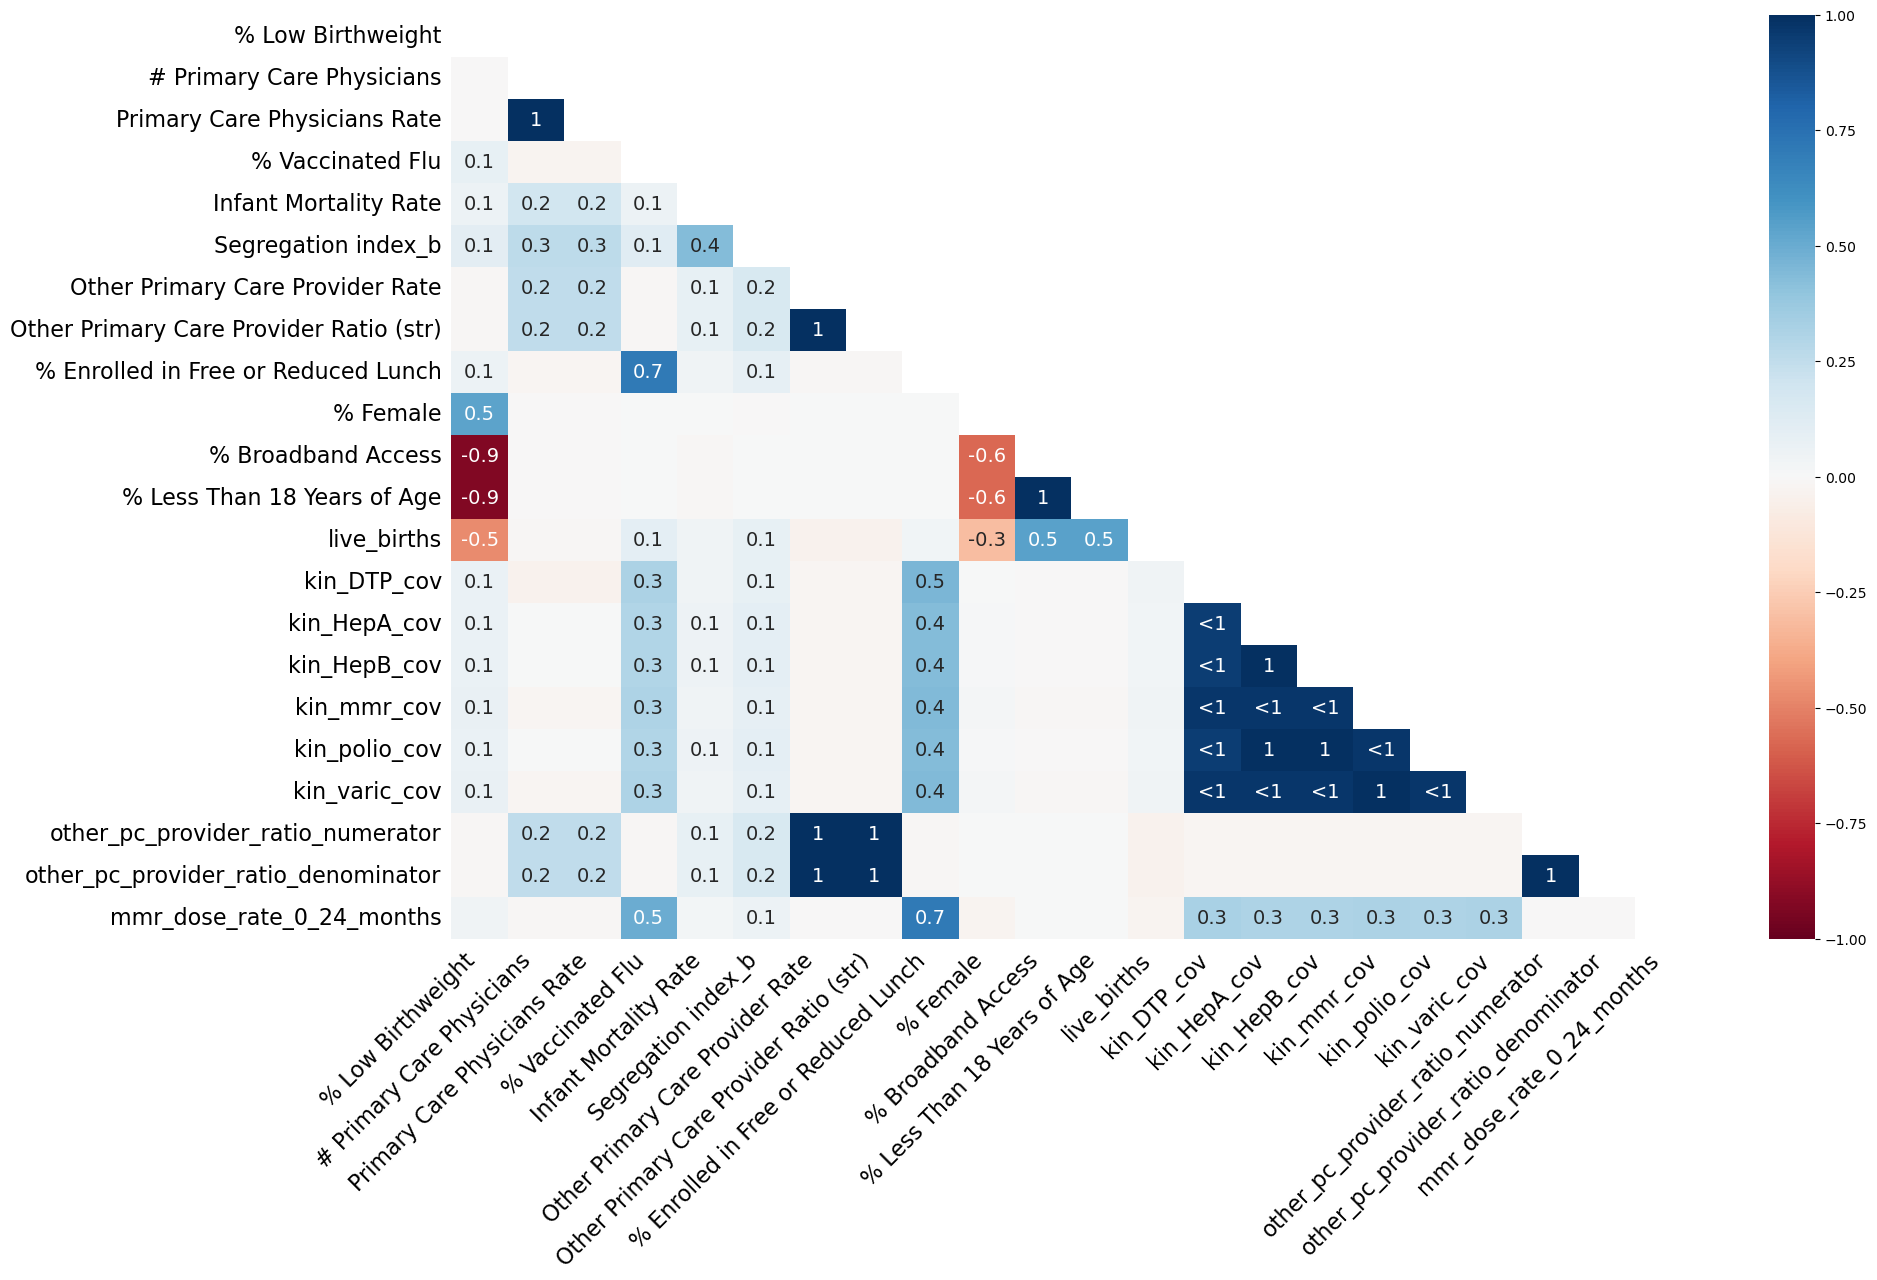

In [537]:
# visually examine patterns in missingness
msno.heatmap(data)

In [538]:
for col in ['% Low Birthweight','% Broadband Access','Segregation index_b','% Female']:
    missing_by_year = data.groupby('year')[col].apply(lambda x: x.isna().mean())
    print(f"\nMissingness in {col} by year:")
    print(missing_by_year)


Missingness in % Low Birthweight by year:
year
2020    0.074803
2021    1.000000
2022    1.000000
2023    0.074803
Name: % Low Birthweight, dtype: float64

Missingness in % Broadband Access by year:
year
2020    1.0
2021    0.0
2022    0.0
2023    1.0
Name: % Broadband Access, dtype: float64

Missingness in Segregation index_b by year:
year
2020    0.334646
2021    0.338583
2022    0.338583
2023    0.346457
Name: Segregation index_b, dtype: float64

Missingness in % Female by year:
year
2020    0.0
2021    0.0
2022    1.0
2023    0.0
Name: % Female, dtype: float64


Notes
% Low birthweight - values are missing for 2021 and 2022 but present for 2020 and 2023, could use average 
% Broadband access - values are missing for 2020 and 2023 but present for 2021 and 2023
% segregation index values don't vary by year, look at missingness by county
% female - values missing for 2022 only - could be imputed with neighboring values


In [539]:
# check to see how mean values vary across years
for col in ['% Low Birthweight','% Broadband Access','% Female']:
    mean_by_year = data.groupby('year')[col].apply(lambda x: x.mean())
    print(f"\nMean value in {col} by year:")
    print(mean_by_year)


Mean value in % Low Birthweight by year:
year
2020    8.072009
2021         NaN
2022         NaN
2023    8.081984
Name: % Low Birthweight, dtype: float64

Mean value in % Broadband Access by year:
year
2020          NaN
2021    73.095962
2022    76.948015
2023          NaN
Name: % Broadband Access, dtype: float64

Mean value in % Female by year:
year
2020    49.064012
2021    49.125907
2022          NaN
2023    48.761255
Name: % Female, dtype: float64


In [540]:
# impute values for the Low Birth weight column for each county based on the values for other years
int_list_2020_2023 = [2020,2023]
int_list_2021_2022 = [2021,2022]

lbw_mean_2020_2023_by_county = (data.loc[data['year'].isin(int_list_2020_2023)]
    .groupby('county_name')['% Low Birthweight']
    .mean()
)
print(lbw_mean_2020_2023_by_county)

county_name
Anderson    7.331794
Andrews     6.804911
Angelina    8.978869
Aransas     9.085330
Archer      7.437144
              ...   
Wood        6.344441
Yoakum      6.222404
Young       4.974780
Zapata      8.327636
Zavala      8.573481
Name: % Low Birthweight, Length: 254, dtype: float64


In [541]:
# for each county replace 2021 and 2022 null values with the mean of 2020 and 2023 values 
mask = (data['year'].isin([2021, 2022])) & (data['% Low Birthweight'].isnull())
data.loc[mask, '% Low Birthweight'] = (
    data.loc[mask, 'county_name'].map(lbw_mean_2020_2023_by_county)
)
print(data.loc[mask, ['county_name', 'year', '% Low Birthweight']].sort_values(by= 'county_name').head())
data.shape

    county_name  year  % Low Birthweight
254    Anderson  2021           7.331794
508    Anderson  2022           7.331794
255     Andrews  2021           6.804911
509     Andrews  2022           6.804911
256    Angelina  2021           8.978869


(1016, 54)

Now the null value for 2021 and 2022 are replaced in with the mean.

In [542]:
# impute values for the % broadband access column for each county based on the values for other years

broadb_mean_2021_2022_by_county = (data.loc[data['year'].isin(int_list_2021_2022)]
    .groupby('county_name')['% Broadband Access']
    .mean()
)
print(broadb_mean_2021_2022_by_county,"\n")

# for each county replace 2020 and 2023 null values with the mean of 2021 and 2022 values 
data_test = data.copy()
mask = (data['year'].isin(int_list_2020_2023)) & (data['% Broadband Access'].isnull())
data_test.loc[mask, '% Broadband Access'] = (
    data_test.loc[mask, 'county_name'].map(broadb_mean_2021_2022_by_county)
)
print(data_test.loc[mask, ['county_name', 'year', '% Broadband Access']].sort_values(by= 'county_name').head())
data_test.shape
data = data_test

county_name
Anderson    71.135936
Andrews     87.630549
Angelina    83.819458
Aransas     83.420779
Archer      76.586926
              ...    
Wood        78.869599
Yoakum      79.277289
Young       77.379648
Zapata      60.193254
Zavala      57.076687
Name: % Broadband Access, Length: 254, dtype: float64 

    county_name  year  % Broadband Access
0      Anderson  2020           71.135936
762    Anderson  2023           71.135936
1       Andrews  2020           87.630549
763     Andrews  2023           87.630549
2      Angelina  2020           83.819458


In [543]:
# impute values for the % Female column for each county based on the values for other years
int_list_2020_2021_2023 = [2022,2021,2023]

female_mean_2020_2021_2023_by_county = (data.loc[data['year']!= 2022]
    .groupby('county_name')['% Female']
    .mean()
)
print(female_mean_2020_2021_2023_by_county,"\n")

# for each county replace 2022 null values with the mean of 2021, 2022 and 2023 values 
data_test = data.copy()
mask = (data['year']== 2022) & (data['% Female'].isnull())
data_test.loc[mask, '% Female'] = (
    data_test.loc[mask, 'county_name'].map(female_mean_2020_2021_2023_by_county)
)
print(data_test.loc[mask, ['county_name', 'year', '% Female']].sort_values(by= 'county_name').head())
data_test.shape
data = data_test

county_name
Anderson    38.460981
Andrews     48.871907
Angelina    51.109349
Aransas     50.431885
Archer      50.747048
              ...    
Wood        50.249727
Yoakum      49.012264
Young       50.214278
Zapata      50.130682
Zavala      49.111035
Name: % Female, Length: 254, dtype: float64 

    county_name  year   % Female
508    Anderson  2022  38.460981
509     Andrews  2022  48.871907
510    Angelina  2022  51.109349
511     Aransas  2022  50.431885
512      Archer  2022  50.747048


Examine patterns in segregation_b missingness by county

In [546]:
data['seg_missing_bool'] = data['Segregation index_b'].isnull()
print(type(data['seg_missing_bool']))
print(data.filter(like ='seg').columns)
print(data['seg_missing_bool'].head())

seg_missing_by_county = (data
    .groupby(['county_name'])['seg_missing_bool']
    .mean()
    .to_frame()
)
print(seg_missing_by_county.head())
print(type(seg_missing_by_county['seg_missing_bool']))
# column now shows the proportion of records (4 years) for each county that were missing

<class 'pandas.core.series.Series'>
Index(['seg_missing_bool'], dtype='object')
0    False
1    False
2    False
3    False
4     True
Name: seg_missing_bool, dtype: bool
             seg_missing_bool
county_name                  
Anderson                 0.00
Andrews                  0.25
Angelina                 0.00
Aransas                  0.50
Archer                   1.00
<class 'pandas.core.series.Series'>


In [547]:
seg_missing_by_county.value_counts()

seg_missing_bool
0.00                158
1.00                 76
0.50                  9
0.75                  6
0.25                  5
Name: count, dtype: int64

Most counties (158) aren't missing any values. 76 are missing all of them, and 20 are missing 1-3 values.

In [548]:
# list all the counties that are missing more than a single year of data
counties_missing_all = seg_missing_by_county.loc[seg_missing_by_county['seg_missing_bool']>0.75].sort_values(by = 'seg_missing_bool').index
print("Counties missing all segregation index_b values for all four years:\n\n", counties_missing_all)

Counties missing all segregation index_b values for all four years:

 Index(['Archer', 'Montague', 'Mills', 'Menard', 'McMullen', 'Mason', 'Martin',
       'Lynn', 'Loving', 'Live Oak', 'Lipscomb', 'La Salle', 'Kinney', 'King',
       'Kimble', 'Kent', 'Motley', 'Kenedy', 'Oldham', 'Presidio', 'Willacy',
       'Throckmorton', 'Terrell', 'Sutton', 'Stonewall', 'Sterling', 'Starr',
       'Somervell', 'Sherman', 'Shackelford', 'Schleicher', 'San Saba',
       'Roberts', 'Real', 'Reagan', 'Parmer', 'Jim Hogg', 'Jeff Davis', 'Jack',
       'Concho', 'Collingsworth', 'Coke', 'Cochran', 'Clay', 'Carson',
       'Callahan', 'Brooks', 'Briscoe', 'Brewster', 'Borden', 'Blanco',
       'Bandera', 'Bailey', 'Armstrong', 'Cottle', 'Crane', 'Crockett',
       'Culberson', 'Irion', 'Hudspeth', 'Hemphill', 'Hartley', 'Hardeman',
       'Hansford', 'Hamilton', 'Zapata', 'Hall', 'Gillespie', 'Foard',
       'Edwards', 'Duval', 'Dimmit', 'Dickens', 'Dallam', 'Glasscock',
       'Zavala'],
      dtype='

I don't see any clear pattern that explains why the segregation index_b is missing. I could impute it but the choice of a fillvalue would be pretty arbitrary. Could use the mean for a given year across all counties.

In [549]:
# impute values for the missing column
x = imputer.fit_transform(data[['Segregation index_b']])
imputed_segregation_df = pd.DataFrame(x, columns = ['segregation_imputed', 'segregation_imputed_yes_no'])

In [550]:
# add imputed variables back to the original data frame
print(f"Original data frame shape: {data.shape}")
print(f"Imputed %segregation index data frame shape: {imputed_segregation_df.shape}")
data_test = pd.concat([data,imputed_segregation_df], axis = 1)
print(f"Combined data frame shape: {data_test.shape}")

Original data frame shape: (1016, 55)
Imputed %segregation index data frame shape: (1016, 2)
Combined data frame shape: (1016, 57)


In [551]:
data = data_test

### Correlations

In [552]:
# originally, there were 37 numerical columns
numerical_cols2 = data.select_dtypes(['int','float']).columns
print(len(numerical_cols2))
numerical_cols2

50


Index(['% Low Birthweight', '# Primary Care Physicians',
       'Primary Care Physicians Rate', '% Vaccinated Flu',
       '% Children in Poverty', 'Infant Mortality Rate',
       '# Uninsured Children', '% Uninsured Children', '# Food Insecure',
       '% Food Insecure', 'Segregation index_b',
       'Other Primary Care Provider Rate', 'Median Household Income',
       '% Enrolled in Free or Reduced Lunch', 'Population', '% Female',
       '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age',
       'mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov',
       'kin_mmr_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant',
       'Estimated hesitant or unsure', 'Estimated strongly hesitant',
       'Social Vulnerability Index (SVI)',
       'CVAC level of concern for vaccination rollout',
       'other_pc_provider_ratio_numerator',
       'other_pc_provider_ratio_denominator'

In [553]:
primary_features = (['mmr_dose_rate_0_24_months',
                     'kin_mmr_cov',
                     'Primary Care Physicians Rate',
                     'other_pc_provider_ratio_numerator',
                     'Infant Mortality Rate',
                     '% Uninsured Children',
                     'Other Primary Care Provider Rate',
                     'Population', 
                     '% Female',
                     'Estimated strongly hesitant',
                     'CVAC level of concern for vaccination rollout']
                     )

In [554]:
secondary_features = (['mmr_dose_rate_0_24_months', 
                       'kin_mmr_cov',
                       '% Low Birthweight',
                       '% Children in Poverty',
                       '% Food Insecure','Segregation index_b',
                       'Median Household Income',
                       '% Enrolled in Free or Reduced Lunch',
                       '% Rural',
                       '% Broadband Access',
                       'Social Vulnerability Index (SVI)',
                       '%_pop_youth_imputed']
                       )

In [555]:
data[secondary_features].dtypes

mmr_dose_rate_0_24_months              float64
kin_mmr_cov                            float64
% Low Birthweight                      float64
% Children in Poverty                  float64
% Food Insecure                        float64
Segregation index_b                    float64
Median Household Income                  int64
% Enrolled in Free or Reduced Lunch    float64
% Rural                                float64
% Broadband Access                     float64
Social Vulnerability Index (SVI)       float64
%_pop_youth_imputed                    float64
dtype: object

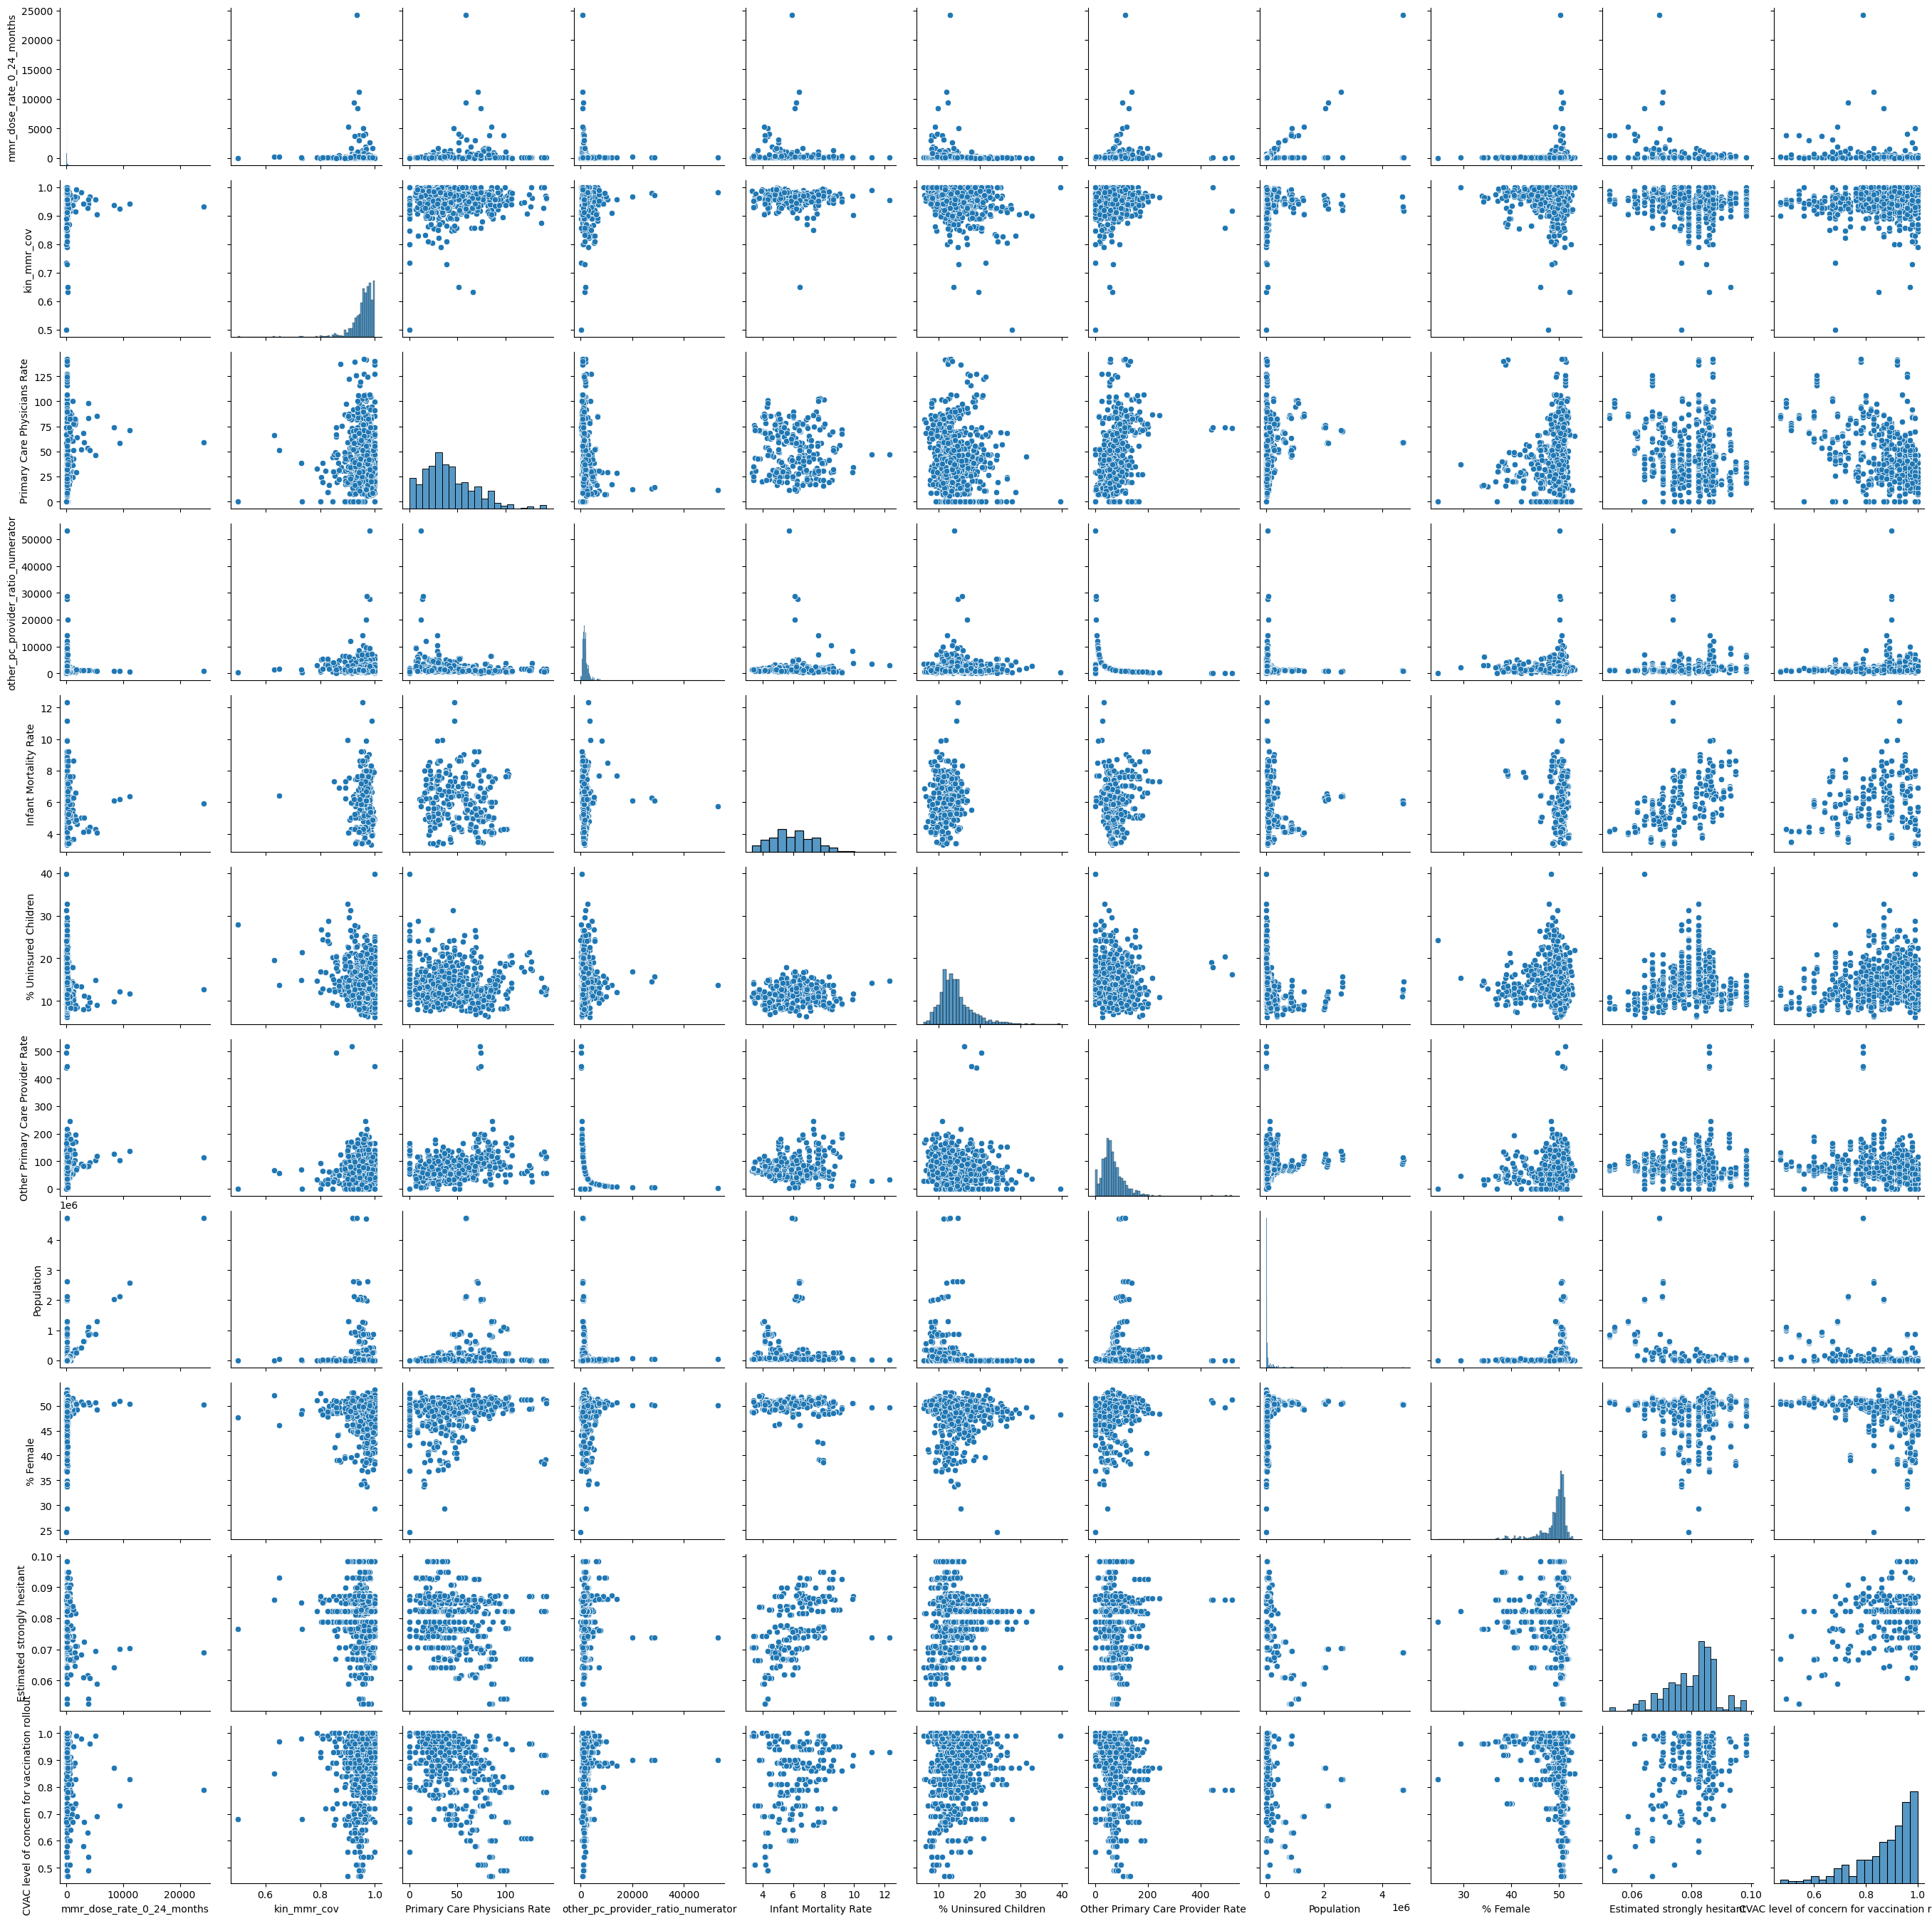

In [556]:
g = sns.PairGrid(data[primary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- The relationship between MMR dose rate 0-24 months is not at all linearly related with the MMR coverage rates among kindergarteners
- There is surprisingly very non-linear relationship betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator' which is a reminder to look more closely at what those variables mean in the documentation.
- IMR appears to be correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. This make sense if the level of concern was based in part on IMR. Maybe more interesting is the association between IMR and COVID-19 vaccine hesitancy.
- % Uninsured Children is correlated with COVID-19 hesitancy levels as well as the CVAC level of concern for COVID-19 roll out. The association between level of concern and % uninsured makes sense makes sense if the level of concern was based in part on the % of uninsured. What's more interesting is the association between % uninsured and the COVID-19 vaccine hesitancy.
- 

In [557]:
primary_features_only = data[primary_features]
(primary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,mmr_dose_rate_0_24_months,kin_mmr_cov,Primary Care Physicians Rate,other_pc_provider_ratio_numerator,Infant Mortality Rate,% Uninsured Children,Other Primary Care Provider Rate,Population,% Female,Estimated strongly hesitant,CVAC level of concern for vaccination rollout
mmr_dose_rate_0_24_months,1.000000,-0.044677,0.099745,-0.047912,-0.075576,-0.081472,0.102274,0.488685,0.051192,-0.164419,-0.100851
kin_mmr_cov,-0.044677,1.000000,-0.005216,0.009913,0.020830,-0.218491,0.008272,-0.048838,-0.003330,-0.057482,0.164000
Primary Care Physicians Rate,0.099745,-0.005216,1.000000,-0.159559,-0.131110,-0.122758,0.399511,0.221842,0.134965,-0.240524,-0.339388
other_pc_provider_ratio_numerator,-0.047912,0.009913,-0.159559,1.000000,0.057689,0.018858,-0.365252,-0.084960,-0.001657,0.073244,0.112904
Infant Mortality Rate,-0.075576,0.020830,-0.131110,0.057689,1.000000,0.139368,0.062439,-0.140222,-0.163076,0.573468,0.254243
% Uninsured Children,-0.081472,-0.218491,-0.122758,0.018858,0.139368,1.000000,-0.055515,-0.182705,-0.056738,0.155823,0.138941
Other Primary Care Provider Rate,0.102274,0.008272,0.399511,-0.365252,0.062439,-0.055515,1.000000,0.155505,0.118273,-0.070043,-0.165980
Population,0.488685,-0.048838,0.221842,-0.084960,-0.140222,-0.182705,0.155505,1.000000,0.116615,-0.346007,-0.226623
% Female,0.051192,-0.003330,0.134965,-0.001657,-0.163076,-0.056738,0.118273,0.116615,1.000000,-0.051760,-0.249338
Estimated strongly hesitant,-0.164419,-0.057482,-0.240524,0.073244,0.573468,0.155823,-0.070043,-0.346007,-0.051760,1.000000,0.259733


Observations

- No correlation between mmr dose rate 0-24 months and the MMR coverage rate
- Note the weak negative correlation betwen the 'Other Primary Care Provider Rate' and the 'other_pc_provider_ratio_numerator'
- Moderate association between **population size** and the % of pop that was strongly hesitant to take the COVID-19 vaccine in 2021, counties with smaller populations have greater % of COVID-19 vaccine hesitancy
- Weak positive correlation between **CVAC level** and MMR coverage rate, makes sense
- Weak negative correlation between **% of uninsured children** in a county and the MMR coverage rate among kindergarteners
- Moderate positive correlation between IMR and % strongly hesistant of COVID-19 vaccine
- Moderate positive correlation between county population and mmr_dose_rate, interesting


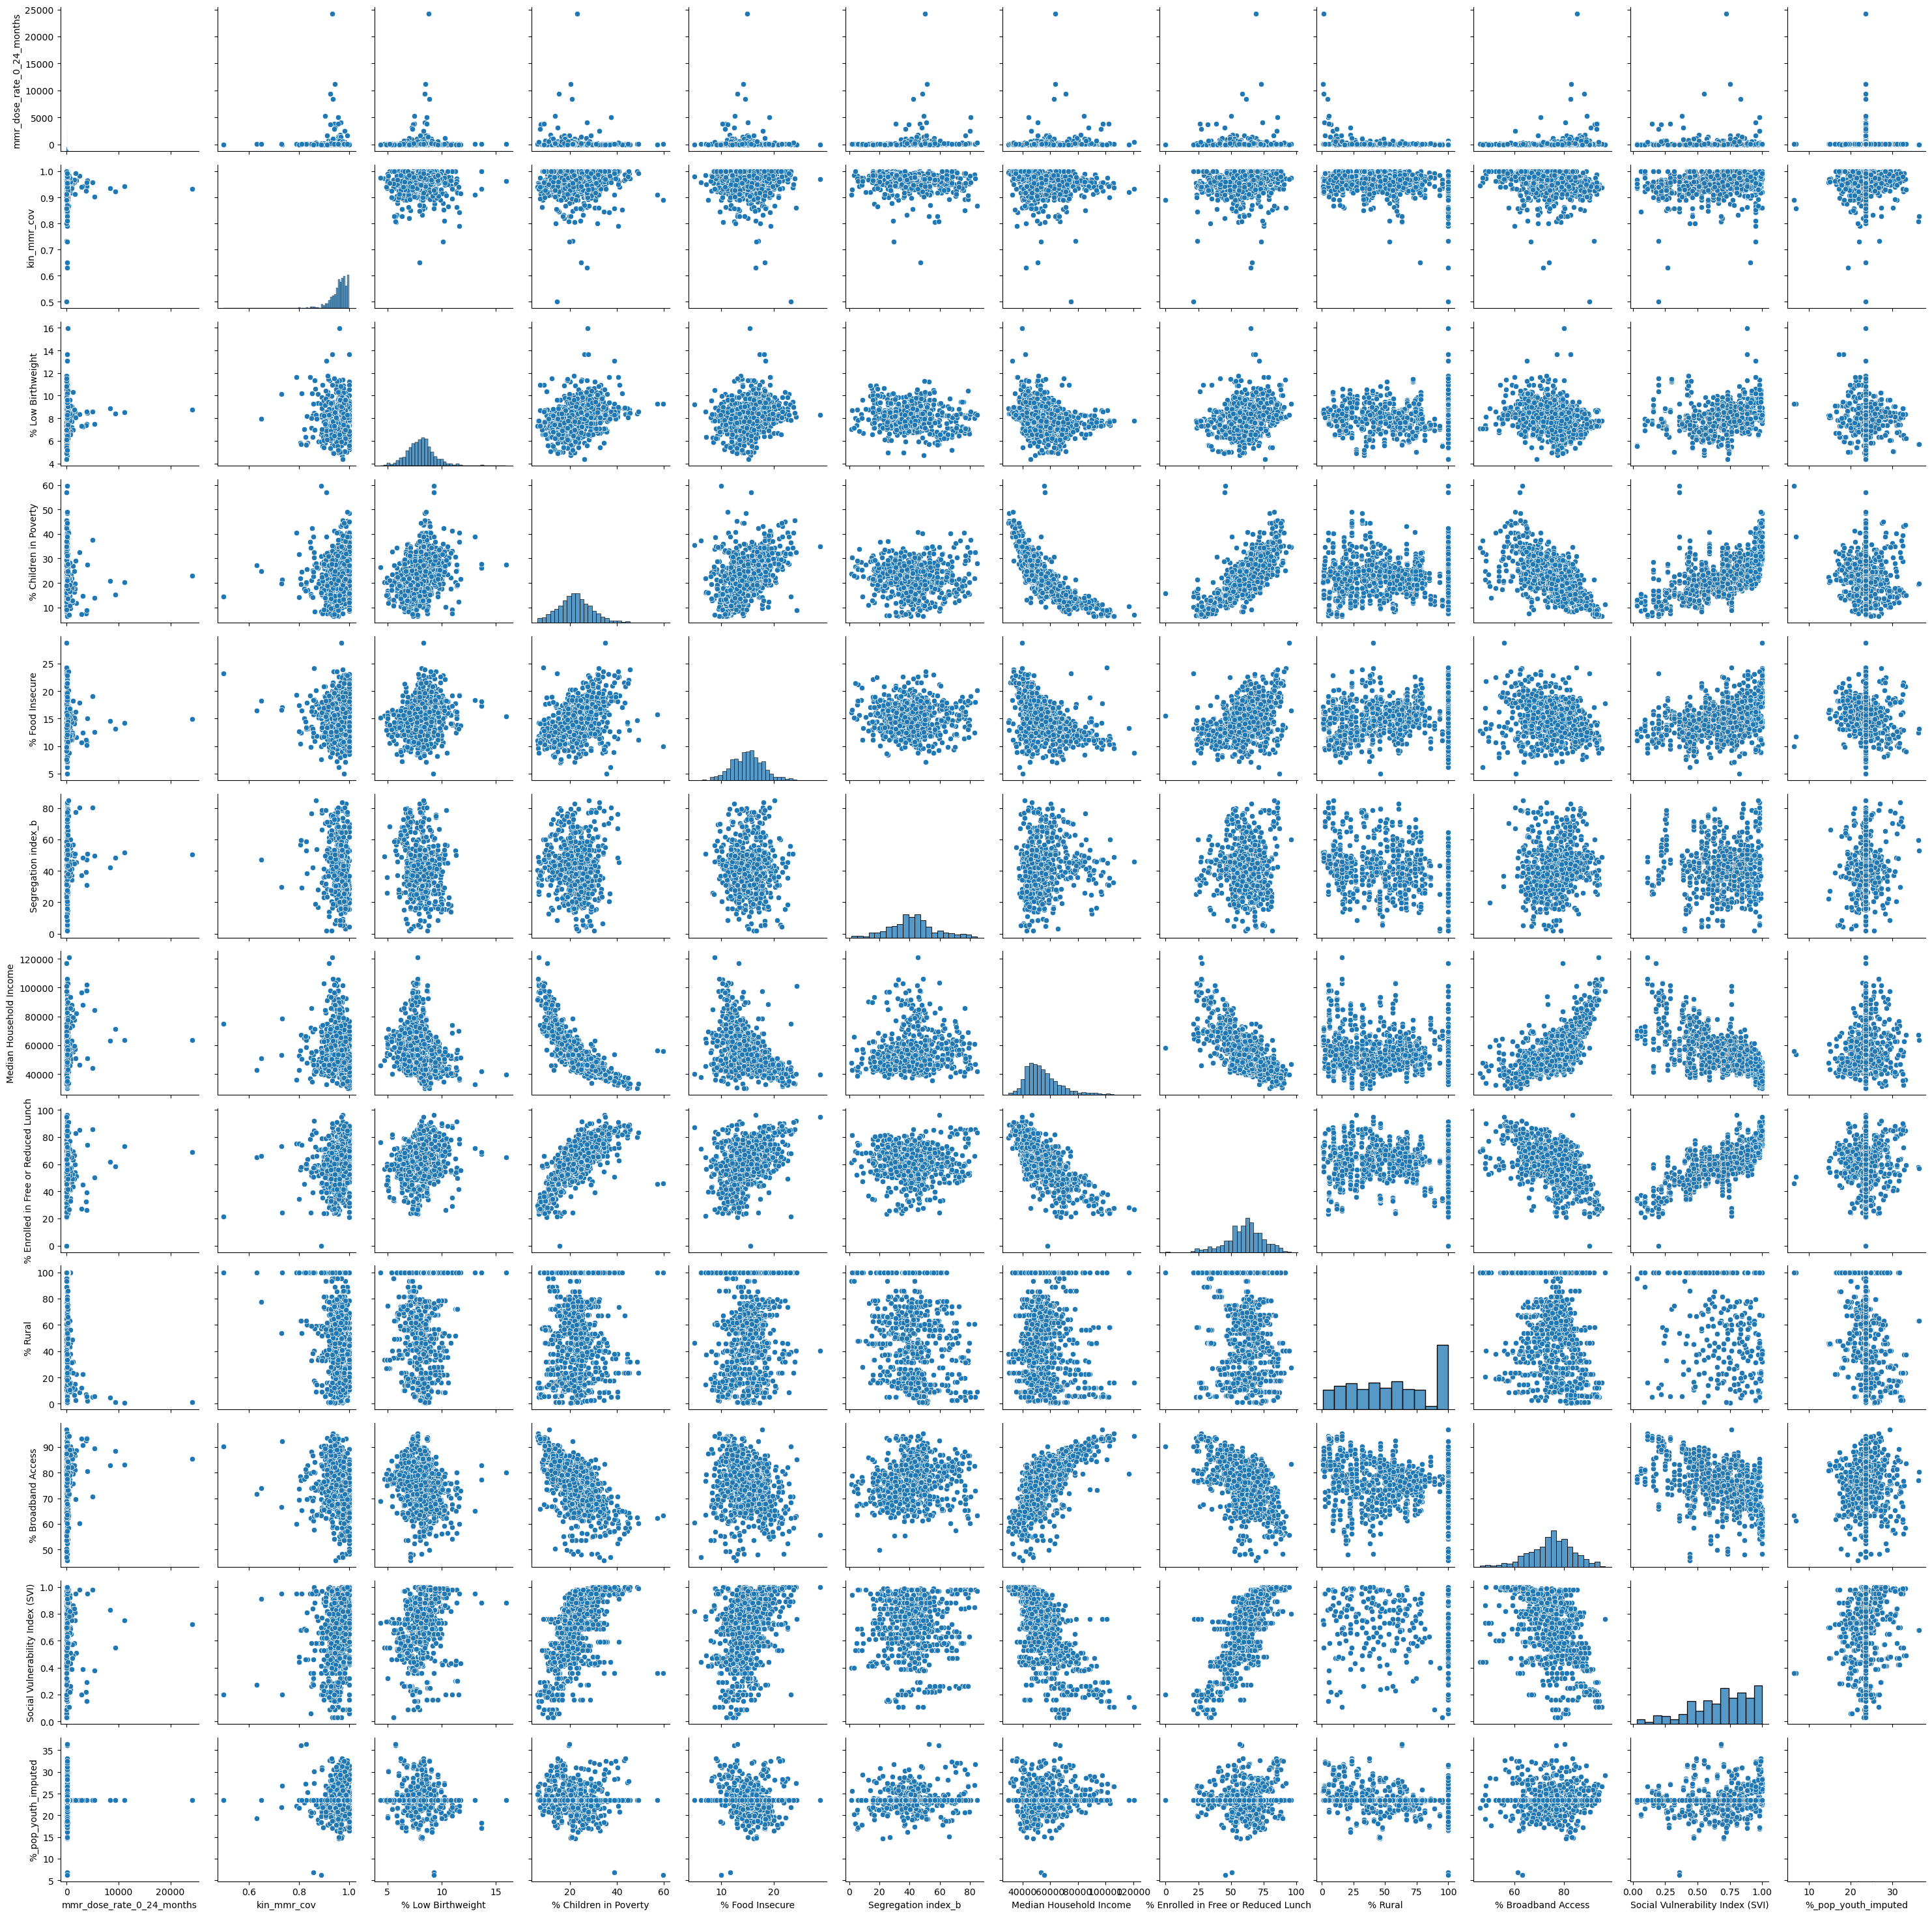

In [558]:
g = sns.PairGrid(data[secondary_features], corner=False, diag_sharey=True, height=2.5, aspect=1, layout_pad=0.5, despine=True, dropna=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)

Observations:
- Notice the homogenous data introduced by the imputed values for % pop_youth_imputed which appears as straight line of dots
- May socieconomic indicators are related in the way one would expect. For example median household income and broadband access are positively correlated at the county level. Poorer counties have less broadban access. Similarily, % children in poverty is positively correlated with the % enrolled in free or reduced lunch
- No clear correlations between the mmr_dose rate and other variables

In [559]:
secondary_features_only = data[secondary_features]
(secondary_features_only
 .corr(method='pearson', numeric_only=True)
 .style
 .background_gradient()
)

,mmr_dose_rate_0_24_months,kin_mmr_cov,% Low Birthweight,% Children in Poverty,% Food Insecure,Segregation index_b,Median Household Income,% Enrolled in Free or Reduced Lunch,% Rural,% Broadband Access,Social Vulnerability Index (SVI),%_pop_youth_imputed
mmr_dose_rate_0_24_months,1.000000,-0.044677,0.027325,-0.048270,-0.034566,0.072882,0.121562,-0.001763,-0.170689,0.123585,-0.012976,-0.005349
kin_mmr_cov,-0.044677,1.000000,0.028804,0.122234,-0.040420,-0.129358,-0.166081,0.175844,-0.114173,-0.170167,0.189726,0.046912
% Low Birthweight,0.027325,0.028804,1.000000,0.316185,0.207852,-0.172029,-0.280610,0.262063,-0.077195,-0.196188,0.280047,-0.070110
% Children in Poverty,-0.048270,0.122234,0.316185,1.000000,0.436234,-0.008932,-0.804950,0.748795,0.076187,-0.638913,0.624278,-0.084030
% Food Insecure,-0.034566,-0.040420,0.207852,0.436234,1.000000,-0.051721,-0.442710,0.388603,0.134902,-0.234611,0.401005,-0.115115
Segregation index_b,0.072882,-0.129358,-0.172029,-0.008932,-0.051721,1.000000,0.078197,0.037864,-0.249073,0.128350,0.002540,0.112653
Median Household Income,0.121562,-0.166081,-0.280610,-0.804950,-0.442710,0.078197,1.000000,-0.724284,-0.162982,0.664185,-0.636349,0.118665
% Enrolled in Free or Reduced Lunch,-0.001763,0.175844,0.262063,0.748795,0.388603,0.037864,-0.724284,1.000000,-0.114148,-0.559920,0.775227,0.076680
% Rural,-0.170689,-0.114173,-0.077195,0.076187,0.134902,-0.249073,-0.162982,-0.114148,1.000000,-0.228666,-0.245413,-0.301342
% Broadband Access,0.123585,-0.170167,-0.196188,-0.638913,-0.234611,0.128350,0.664185,-0.559920,-0.228666,1.000000,-0.453512,0.053878


Observations:
- Weak associationgs between MMR coverage rate among kindergarteners and **% of children in poverty (positive association)**, **median household income (negative)**, **% enrolled in free or reduced lunch (positive)**, and **SVI (positive)**. 
- Strong correlations among SVI, % enrolled in free or reduced lunch, % food insecure, % broadband access, and median household income probably indicate I'll run into collinearity problems if I try to throw all of those in a single model
- Like the pair plot, there are no strong associations between mmr_dose_rate and any of the features


#### Plots for MMR Dose Count

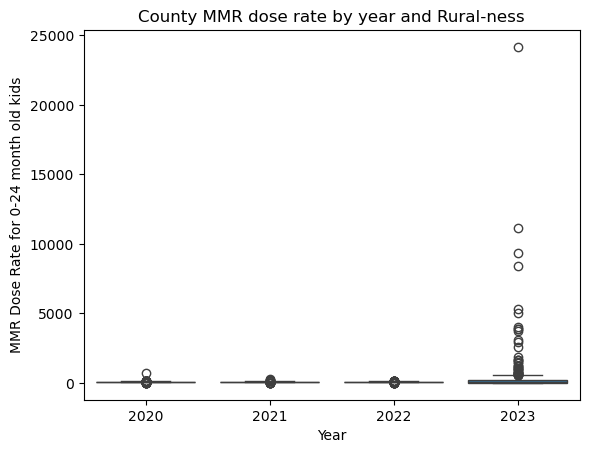

In [560]:
# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'mmr_dose_rate_0_24_months', data = data)

# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and Rural-ness')
# Show the plot
plt.show()

In [561]:
print(data['year'].dtype)

int64


Its a bit curious that the mmr dose rate sky rockets in 2023. The variation is much less in the 3 preceding years.

<class 'pandas.core.series.Series'>


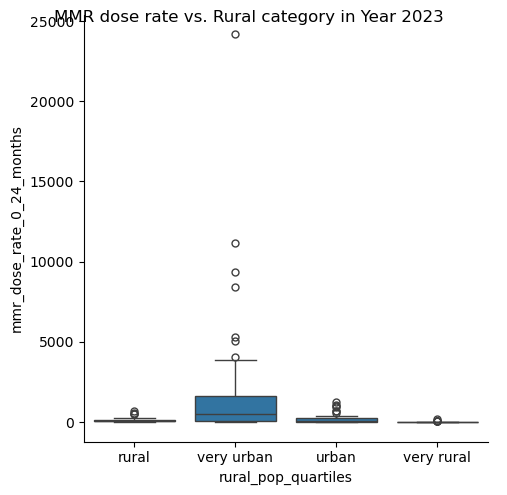

In [562]:
# make a box plot showing distribution of a mmr dose rates in 2023
mask2023 = data['year'] == 2023
print(type(mask2023))
data2023 = data.loc[mask2023,:]

g = sns.catplot(data= data2023, x = "rural_pop_quartiles", y = "mmr_dose_rate_0_24_months", kind = "box")
g.fig.suptitle("MMR dose rate vs. Rural category in Year 2023")
plt.show()

Observation: 

Very large variation of dose rate in the most urban counties in 2023. Examine the relationship between mmr_dose rate and population in the most urban counties.

In [563]:
print("Distribution of dose rate in 0-24 month old kids in 2020:")
print(data.loc[data['year'] ==2020,'mmr_dose_rate_0_24_months'].describe())
print("\nDistribution of dose rate in 0-24 month old kids in 2021:")
print(data.loc[data['year'] ==2021,'mmr_dose_rate_0_24_months'].describe())
print("\nDistribution of dose rate in 0-24 month old kids in 2022:")
print(data.loc[data['year'] ==2022,'mmr_dose_rate_0_24_months'].describe())
print("\nDistribution of dose rate in 0-24 month old kids in 2023:")
data.loc[data['year'] ==2023,'mmr_dose_rate_0_24_months'].describe()

Distribution of dose rate in 0-24 month old kids in 2020:
count    253.000000
mean      79.250039
std       46.048096
min        0.000000
25%       62.906340
50%       75.507219
75%       86.767688
max      679.610365
Name: mmr_dose_rate_0_24_months, dtype: float64

Distribution of dose rate in 0-24 month old kids in 2021:
count    253.000000
mean      78.161652
std       27.732338
min        0.000000
25%       64.903367
50%       76.892768
75%       87.581367
max      272.679540
Name: mmr_dose_rate_0_24_months, dtype: float64

Distribution of dose rate in 0-24 month old kids in 2022:
count    254.000000
mean      73.897398
std       24.054003
min        0.000000
25%       63.467646
50%       73.926603
75%       83.792659
max      174.115763
Name: mmr_dose_rate_0_24_months, dtype: float64

Distribution of dose rate in 0-24 month old kids in 2023:


count      254.000000
mean       527.612969
std       1957.285856
min          0.000000
25%         22.146184
50%         70.561512
75%        235.726669
max      24167.180325
Name: mmr_dose_rate_0_24_months, dtype: float64

Large st deviation of MMR dose rate. Median is 70 doses per child would suggest that my estimates of the # of children are UNDERestimates by a large margin for all years, especially 2020-2022. Then in 2023, the variation sky rockets but the median actually decreases???

In [564]:
data.filter(like = 'mmr').columns

Index(['mmr_doses_0_24_months', 'mmr_doses_2_8_years', 'mmr_doses_9_17_years',
       'kin_mmr_cov', 'mmr_dose_rate_0_24_months', 'mmr_doses_<18yrs',
       'mmr_dose_rate_<18yrs'],
      dtype='object')

In [565]:
# view the top 10 counties and their populations with the highest mmr dose rate per child in 2023
mask = (data['mmr_dose_rate_0_24_months']>82) & (data['year'] ==2023)
type(mask)
data.loc[mask, ['county_name','pop_0_24mos','mmr_doses_0_24_months','mmr_dose_rate_0_24_months']].sort_values('mmr_dose_rate_0_24_months', ascending = False).head(10)

,county_name,pop_0_24mos,mmr_doses_0_24_months,mmr_dose_rate_0_24_months
862,Harris,212.234110,51291.0,24167.180325
818,Dallas,212.141772,23634.0,11140.663063
981,Tarrant,212.176845,19824.0,9343.149566
776,Bexar,212.193254,17833.0,8404.131440
988,Travis,212.626964,11309.0,5318.704555
869,Hidalgo,212.580208,10714.0,5039.980020
831,El Paso,212.554317,8591.0,4041.790410
840,Fort Bend,212.613911,8210.0,3861.459471
804,Collin,212.579295,8177.0,3846.564639
823,Denton,212.582434,7963.0,3745.841006


Is it possible that in these urban areas, there is a serious undercount of kids 0-24 months? That might explain in part why the dose rates are so high.
But it's not clear why this pattern appears in 2023 and not in previous years. See table below.

In [566]:
# see how this list compares to the previous year, 2022

mask2022 = (data['mmr_dose_rate_0_24_months']>82) & (data['year'] ==2022)
data.loc[mask2022, ['county_name','pop_0_24mos','mmr_doses_0_24_months', 'mmr_dose_rate_0_24_months']].sort_values('mmr_dose_rate_0_24_months', ascending = False).head(10)

,county_name,pop_0_24mos,mmr_doses_0_24_months,mmr_dose_rate_0_24_months
530,Briscoe,12.922437,22.5,174.115763
671,Menard,11.928404,20.0,167.667031
680,Motley,10.934370,17.5,160.045802
555,Concho,12.922437,20.0,154.769567
572,Donley,17.892605,27.5,153.694778
622,Hudspeth,24.850841,37.5,150.900328
570,Dickens,17.892605,25.0,139.722526
576,Edwards,19.880673,25.0,125.750273
723,Sterling,17.892605,22.5,125.750273
611,Haskell,32.803110,40.0,121.939659


In [567]:
# look at the counties that had large populations (67% percentile or greater)  in 2023
bigpop2023mask = (data['pop_tertiles'] == 'large') & (data['year'] == 2023)
print(len(data.loc[bigpop2023mask,['county_name', 'Population']])) # count the # of counties

# view the mmr_dose rates for the most urban counties in 2023
data.loc[bigpop2023mask,['county_name', 'year','Population', 'mmr_doses_0_24_months','mmr_dose_rate_0_24_months']].sort_values(['mmr_dose_rate_0_24_months'], ascending = False).head(10)

84


,county_name,year,Population,mmr_doses_0_24_months,mmr_dose_rate_0_24_months
862,Harris,2023,4728030,51291.0,24167.180325
818,Dallas,2023,2586050,23634.0,11140.663063
981,Tarrant,2023,2126477,19824.0,9343.149566
776,Bexar,2023,2028236,17833.0,8404.131440
988,Travis,2023,1305154,11309.0,5318.704555
869,Hidalgo,2023,880356,10714.0,5039.980020
831,El Paso,2023,867947,8591.0,4041.790410
840,Fort Bend,2023,858527,8210.0,3861.459471
804,Collin,2023,1109462,8177.0,3846.564639
823,Denton,2023,941647,7963.0,3745.841006


#### Plots for MMR Coverage

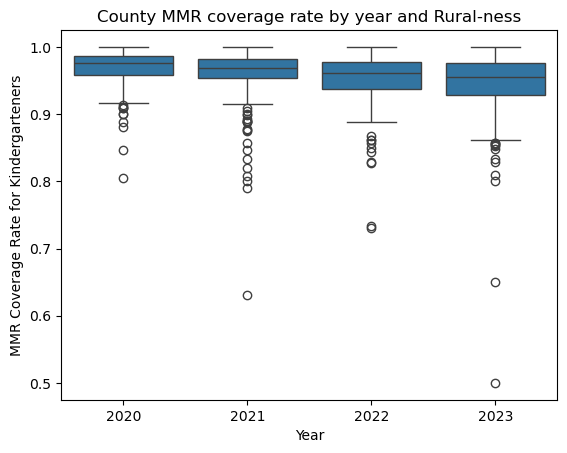

In [568]:
# Make box plot of by year
_ = sns.boxplot(x = 'year', y = 'kin_mmr_cov', data = data)

# Label the axes
_ = plt.xlabel('Year')
_ = plt.ylabel('MMR Coverage Rate for Kindergarteners')
_ = plt.title('County MMR coverage rate by year and Rural-ness')
# Show the plot
plt.show()

At the same time that MMR dose counts sky rocketed in 2023, MMR coverage rates seem to trend downward as shown in the box plot above. In both the MMR count and MMR coverage box plots, variation seems to increase year over year.

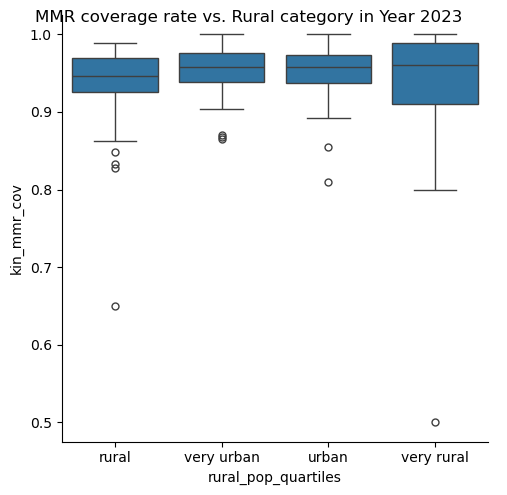

In [569]:
# make a box plot showing distribution of a mmr coverage rates in 2023
g = sns.catplot(data= data2023, x = "rural_pop_quartiles", y = "kin_mmr_cov", kind = "box")
g.fig.suptitle("MMR coverage rate vs. Rural category in Year 2023")
plt.show()

Doesn't appear to be a linear relationship with rural county categories.... maybe it would look different if we considered 'rural'ness as a continuous variable. Variation largest in very rural counties, there are about 10 outliers it may make sense to recode. 

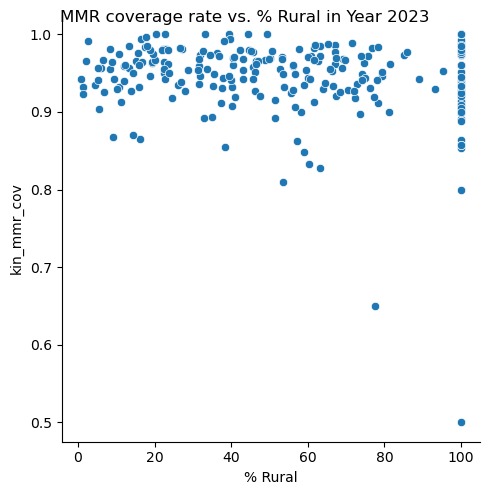

In [570]:
# make a box plot showing distribution of a mmr coverage rates in 2023
g = sns.relplot(data= data2023, x = "% Rural", y = "kin_mmr_cov")
g.fig.suptitle("MMR coverage rate vs. % Rural in Year 2023")
plt.show()

In [571]:
# For 2023, view the counties with the top 10 kindergarten MMR coverage rates and their populations alongside their mmr dose count rate per child
mask2023 = (data['year'] ==2023)
data.loc[mask2023, ['county_name', 'kin_mmr_cov', 'mmr_dose_rate_0_24_months','rural_pop_quartiles']].sort_values('kin_mmr_cov', ascending = True).head(10)

,county_name,kin_mmr_cov,mmr_dose_rate_0_24_months,rural_pop_quartiles
896,King,0.500000,0.000000,very rural
948,Polk,0.650284,148.492594,rural
839,Foard,0.800000,7.067931,very rural
908,Limestone,0.809859,93.296690,urban
844,Gaines,0.828125,89.527127,rural
828,Eastland,0.832558,70.443713,rural
930,Montague,0.848624,75.391264,rural
857,Hall,0.852941,11.779885,very rural
889,Karnes,0.854396,47.826333,urban
777,Blanco,0.855932,25.208954,very rural


The counties with the lowest MMR coverage rates at kindergarten also have fairly low MMR dose rates. 
King and Polk seem like definite outliers, they're the only two counties with <80% MMR coverage among kindergarteners and they are both rural.

In [572]:
# For 2022, view the counties with the top 10 kindergarten MMR coverage rates and their populations alongside their mmr dose count rate per child
mask2022 = (data['year'] ==2022)
data.loc[mask2022, ['county_name', 'kin_mmr_cov', 'mmr_dose_rate_0_24_months','rural_pop_quartiles']].sort_values('kin_mmr_cov', ascending = True).head(10)

,county_name,kin_mmr_cov,mmr_dose_rate_0_24_months,rural_pop_quartiles
654,Limestone,0.730104,65.961315,urban
642,King,0.733333,1.177989,very rural
718,Sherman,0.826923,58.861830,very rural
590,Gaines,0.828571,42.437351,rural
603,Hall,0.843750,107.785948,very rural
618,Hood,0.849862,87.122855,urban
530,Briscoe,0.857143,174.115763,very rural
631,Jim Hogg,0.860759,61.907827,very urban
696,Presidio,0.861111,54.347244,urban
676,Montague,0.867521,74.757961,rural


## Clean and examine categorical variables

In [573]:
categorical_cols = data.select_dtypes(['object']).columns
print(len(categorical_cols))
categorical_cols

6


Index(['county_name', 'Other Primary Care Provider Ratio (str)',
       'SVI Category', 'CVAC Level Of Concern', 'pop_tertiles',
       'rural_pop_quartiles'],
      dtype='object')

In [574]:
data['SVI Category'].unique()

array(['High Vulnerability', 'Moderate Vulnerability',
       'Very High Vulnerability', 'Very Low Vulnerability',
       'Low Vulnerability'], dtype=object)

In [575]:
data['CVAC Level Of Concern'].unique()

array(['Very High Concern', 'Moderate Concern', 'High Concern'],
      dtype=object)

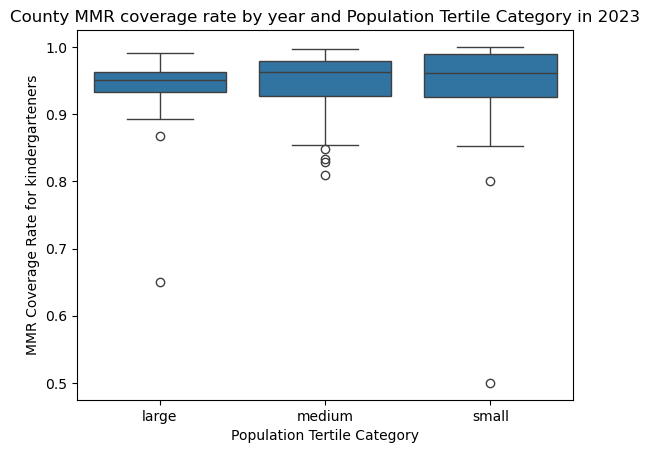

In [576]:
# Make box plot of mmr dose rate by year and category 
_ = sns.boxplot(x = 'pop_tertiles', y = 'kin_mmr_cov', data = data2023)

# Label the axes
_ = plt.xlabel('Population Tertile Category')
_ = plt.ylabel('MMR Coverage Rate for kindergarteners')
_ = plt.title('County MMR coverage rate by year and Population Tertile Category in 2023')
# Show the plot
plt.show()

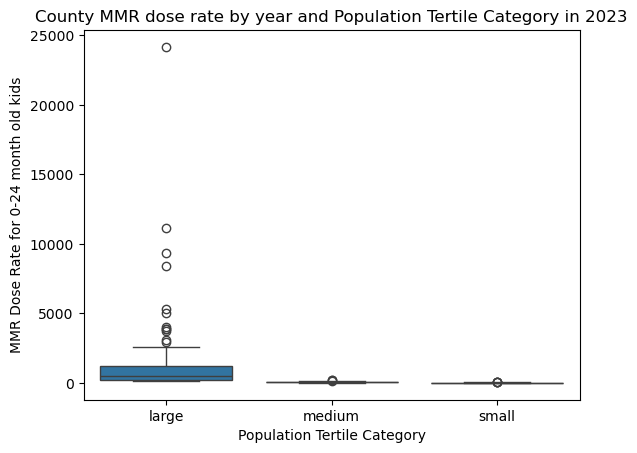

In [577]:
# Make box plot of mmr dose rate by year and category 
_ = sns.boxplot(x = 'pop_tertiles', y = 'mmr_dose_rate_0_24_months', data = data2023)

# Label the axes
_ = plt.xlabel('Population Tertile Category')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and Population Tertile Category in 2023')
# Show the plot
plt.show()

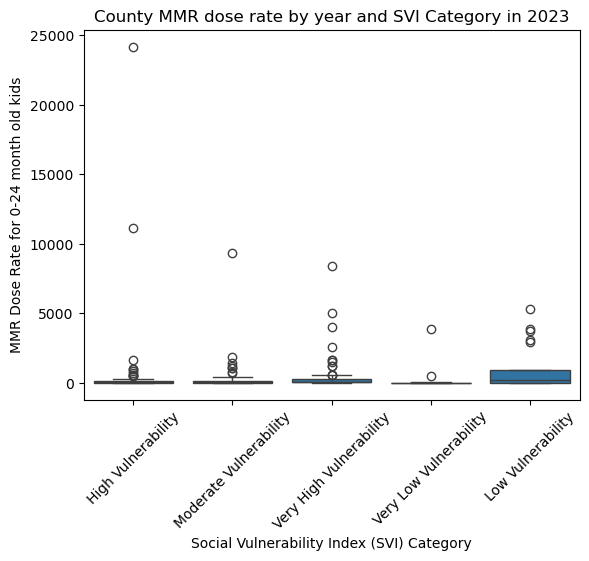

In [578]:
# Make box plot of mmr dose rate by year and category 
_ = sns.boxplot(x = 'SVI Category', y = 'mmr_dose_rate_0_24_months', data = data2023)
# Rotate x-axis tick labels
_ = plt.tick_params(axis='x', rotation=45)
# Label the axes
_ = plt.xlabel('Social Vulnerability Index (SVI) Category')
_ = plt.ylabel('MMR Dose Rate for 0-24 month old kids')
_ = plt.title('County MMR dose rate by year and SVI Category in 2023')
# Show the plot
plt.show()

Interesting that there is the highest variation in MMR dose rate in the counties with the highest proportion of vulnerable individuals. The dose rate in some of these counties is presumably even larger than the dose rate. incounties with a smaller proportion of vulnerable residents.

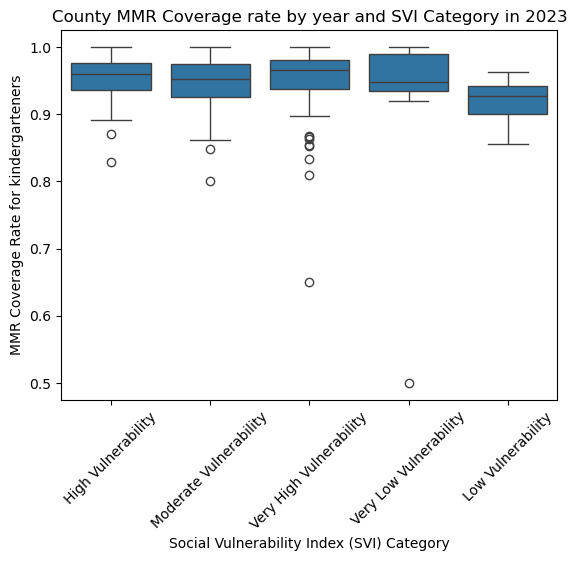

In [579]:
# Make box plot of mmr coverage rate by year and category 
_ = sns.boxplot(x = 'SVI Category', y = 'kin_mmr_cov', data = data2023)
# Rotate x-axis tick labels
_ = plt.tick_params(axis='x', rotation=45)
# Label the axes
_ = plt.xlabel('Social Vulnerability Index (SVI) Category')
_ = plt.ylabel('MMR Coverage Rate for kindergarteners')
_ = plt.title('County MMR Coverage rate by year and SVI Category in 2023')
# Show the plot
plt.show()

# Save modified data

In [580]:
cd '/Users/grace/Documents/GitHubRepos/capstone2_immunization/'

/Users/grace/Documents/GitHubRepos/capstone2_immunization


In [581]:
# save the data to a new csv file
data.to_csv('imm_df_cleaner.csv', index=False) # don't save index as separate column